In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom, t as t_dist

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


In [ ]:
pv = pd.read_csv('pv_student.csv', parse_dates=['Datetime'])
pv = pv.sort_values('Datetime').reset_index(drop=True)

# Filter out hours with zero actuals
pv_active = pv[pv['Actuals'] > 0].copy()

print(f"Total hours:  {len(pv):,}")
print(f"Active hours: {len(pv_active):,}  ({len(pv_active)/len(pv)*100:.1f}%)")
print(f"Date range:   {pv['Datetime'].min()} → {pv['Datetime'].max()}")


Total hours:  26,280
Active hours: 15,889  (60.5%)
Date range:   2013-01-01 00:00:00+00:00 → 2015-12-31 23:00:00+00:00


In [3]:
# Fixed denominator S — computed once over full 2013-2015 active hours
S_pv = pv_active['Actuals'].mean()
print(f"S_pv (global) = {S_pv:.4f}")

# Sensitivity check: per-year S values
for year in [2013, 2014, 2015]:
    s_yr = pv_active[pv_active['Datetime'].dt.year == year]['Actuals'].mean()
    dev = (s_yr - S_pv) / S_pv * 100
    print(f"  S_{year} = {s_yr:.4f}  (deviation: {dev:+.1f}%)")



S_pv (global) = 1.7627
  S_2013 = 1.7610  (deviation: -0.1%)
  S_2014 = 1.6793  (deviation: -4.7%)
  S_2015 = 1.8476  (deviation: +4.8%)


In [5]:
# Compute error series: error = Actuals - Simulation
pv_active = pv_active.copy()
pv_active['error'] = pv_active['Actuals'] - pv_active['Simulation']

def compute_metrics(df, S):
    """Return nMAE, nRMSE, MBE, EDF, Bias_share for a given subset."""
    error = df['error']
    mae   = error.abs().mean()
    rmse  = np.sqrt((error ** 2).mean())
    mbe   = error.mean()
    mse   = (error ** 2).mean()
    return {
        'nMAE':       round(mae / S, 4),
        'nRMSE':      round(rmse / S, 4),
        'MBE':        round(mbe / S, 4),
        'EDF':        round(rmse / mae, 4),
        'Bias_share': round(mbe ** 2 / mse, 4)
    }
rows = {}
for year in [2013, 2014, 2015]:
    subset = pv_active[pv_active['Datetime'].dt.year == year]
    rows[str(year)] = compute_metrics(subset, S_pv)
rows['Full'] = compute_metrics(pv_active, S_pv)

phase_a_pv = pd.DataFrame(rows).T
print("Phase A — PV Annual Overview")
print(phase_a_pv.to_string())

Phase A — PV Annual Overview
        nMAE   nRMSE     MBE     EDF  Bias_share
2013  0.5342  0.8936  0.0662  1.6729      0.0055
2014  0.5255  0.8716 -0.0294  1.6587      0.0011
2015  0.4721  0.8053  0.0765  1.7057      0.0090
Full  0.5106  0.8576  0.0378  1.6797      0.0019


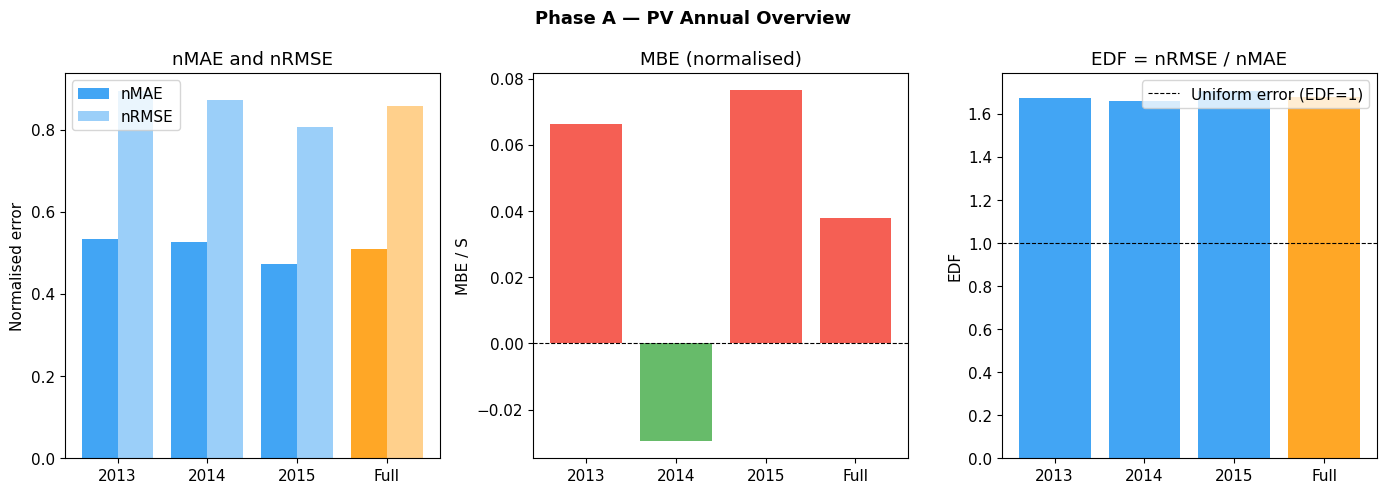

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

years = ['2013', '2014', '2015', 'Full']
x = np.arange(len(years))
colors = ['#2196F3', '#2196F3', '#2196F3', '#FF9800']

# nMAE and nRMSE
axes[0].bar(x - 0.2, phase_a_pv['nMAE'],  0.4, label='nMAE',  color=colors, alpha=0.85)
axes[0].bar(x + 0.2, phase_a_pv['nRMSE'], 0.4, label='nRMSE', color=colors, alpha=0.45)
axes[0].set_title('nMAE and nRMSE')
axes[0].set_xticks(x); axes[0].set_xticklabels(years)
axes[0].legend()
axes[0].set_ylabel('Normalised error')

# MBE
bar_colors = ['#F44336' if v > 0 else '#4CAF50' for v in phase_a_pv['MBE']]
axes[1].bar(x, phase_a_pv['MBE'], color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('MBE (normalised)')
axes[1].set_xticks(x); axes[1].set_xticklabels(years)
axes[1].set_ylabel('MBE / S')

# EDF
axes[2].bar(x, phase_a_pv['EDF'], color=colors, alpha=0.85)
axes[2].axhline(1, color='black', linewidth=0.8, linestyle='--', label='Uniform error (EDF=1)')
axes[2].set_title('EDF = nRMSE / nMAE')
axes[2].set_xticks(x); axes[2].set_xticklabels(years)
axes[2].set_ylabel('EDF')
axes[2].legend()

plt.suptitle('Phase A — PV Annual Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_a_pv.png', dpi=150, bbox_inches='tight')
plt.show()


/var/folders/lw/9rf5ssf12y57gz5nz8d45rlc0000gn/T/ipykernel_54875/3313440081.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  pv_active['ym']    = pv_active['Datetime'].dt.to_period('M')


           nMAE   nRMSE     MBE     EDF  Bias_share
period                                             
2013-01  0.2974  0.4520  0.2290  1.5199      0.2566
2013-02  0.4268  0.6538 -0.0374  1.5320      0.0033
2013-03  0.6253  0.9200 -0.0918  1.4712      0.0100
2013-04  0.6231  0.9644  0.3077  1.5478      0.1018
2013-05  0.7635  1.1902  0.2813  1.5589      0.0559
2013-06  0.6112  1.0498  0.0400  1.7175      0.0015
2013-07  0.5818  0.9462 -0.2276  1.6264      0.0578
2013-08  0.5938  1.0199  0.1005  1.7177      0.0097
2013-09  0.6887  1.0284  0.1105  1.4933      0.0116
2013-10  0.4638  0.7386 -0.0161  1.5926      0.0005
2013-11  0.2262  0.3817  0.0864  1.6876      0.0512
2013-12  0.1779  0.2968  0.0317  1.6677      0.0114
2014-01  0.1918  0.3126 -0.0278  1.6298      0.0079
2014-02  0.4253  0.6297 -0.0786  1.4806      0.0156
2014-03  0.5992  0.8503 -0.2340  1.4191      0.0758
2014-04  0.5133  0.8330  0.1737  1.6230      0.0435
2014-05  0.7421  1.1460 -0.4088  1.5443      0.1273
2014-06  0.5

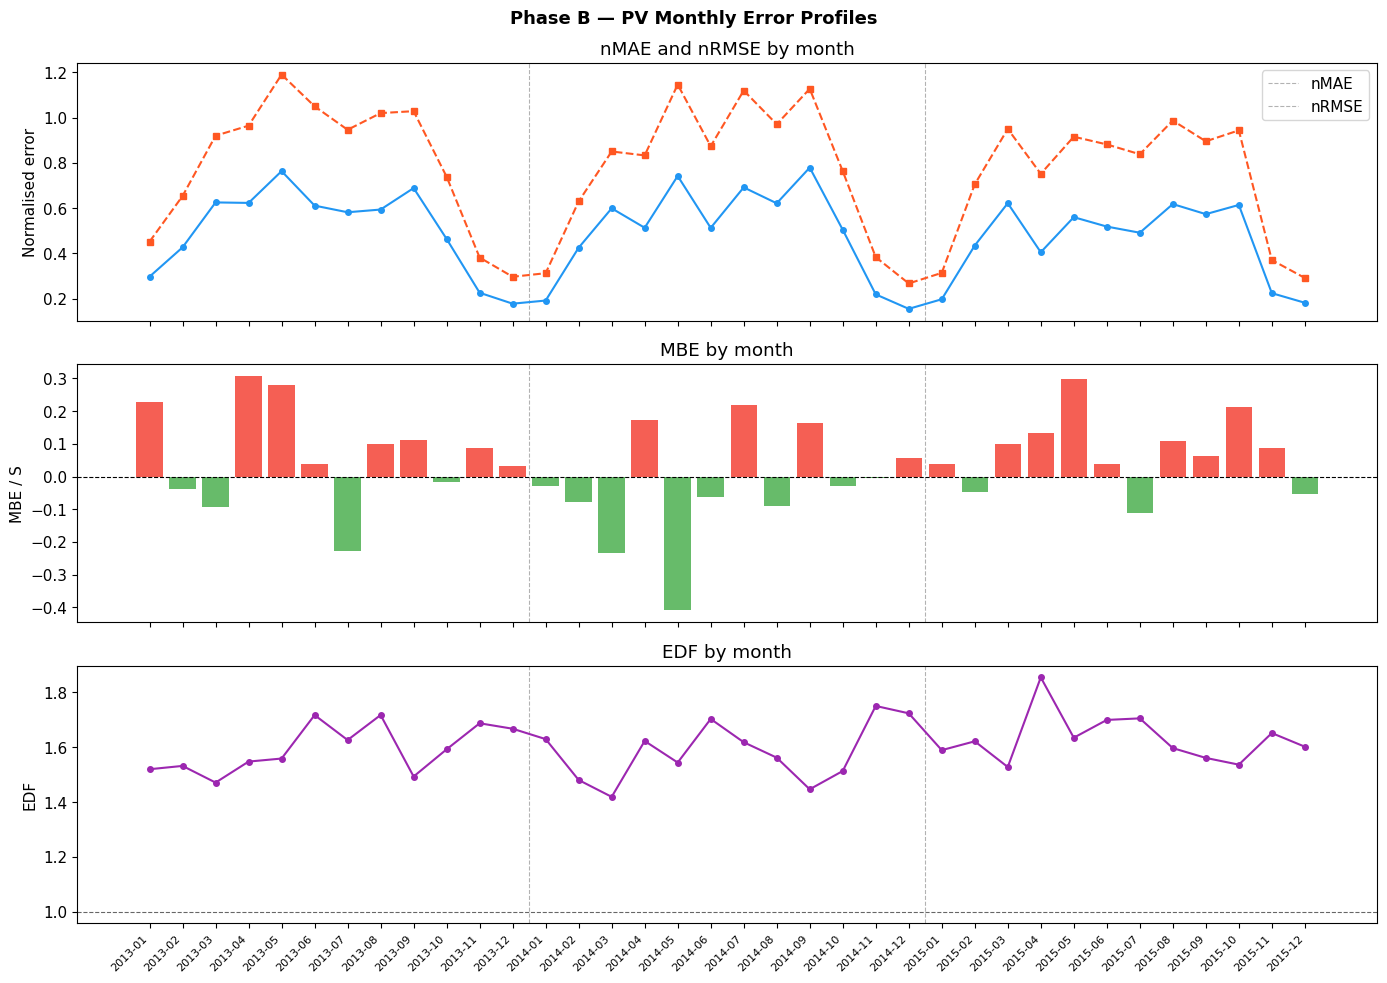

In [7]:
# Monthly error metrics for all 36 months (Jan 2013 – Dec 2015)
pv_active['year']  = pv_active['Datetime'].dt.year
pv_active['month'] = pv_active['Datetime'].dt.month
pv_active['ym']    = pv_active['Datetime'].dt.to_period('M')

monthly_rows = []
for ym, group in pv_active.groupby('ym'):
    m = compute_metrics(group, S_pv)
    m['period'] = ym
    monthly_rows.append(m)

monthly_pv = pd.DataFrame(monthly_rows).set_index('period').sort_index()
print(monthly_pv.to_string())

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

x = np.arange(len(monthly_pv))
labels = [str(p) for p in monthly_pv.index]

# Add vertical lines to separate years
year_breaks = [12, 24]

for ax in axes:
    for xb in year_breaks:
        ax.axvline(xb - 0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

axes[0].plot(x, monthly_pv['nMAE'],  marker='o', markersize=4, color='#2196F3')
axes[0].plot(x, monthly_pv['nRMSE'], marker='s', markersize=4, color='#FF5722', linestyle='--')
axes[0].set_ylabel('Normalised error')
axes[0].set_title('nMAE and nRMSE by month')
axes[0].legend(['nMAE', 'nRMSE'])

axes[1].bar(x, monthly_pv['MBE'],
            color=['#F44336' if v > 0 else '#4CAF50' for v in monthly_pv['MBE']],
            alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_ylabel('MBE / S')
axes[1].set_title('MBE by month')

axes[2].plot(x, monthly_pv['EDF'], marker='o', markersize=4, color='#9C27B0')
axes[2].axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
axes[2].set_ylabel('EDF')
axes[2].set_title('EDF by month')

axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

plt.suptitle('Phase B — PV Monthly Error Profiles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_b_pv_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
from scipy import stats

# Group by calendar month (1-12)
monthly_abs = [
    pv_active.loc[pv_active['month'] == m, 'error'].abs().values
    for m in range(1, 13)
]
monthly_signed = [
    pv_active.loc[pv_active['month'] == m, 'error'].values
    for m in range(1, 13)
]

# Primary: error magnitude
kw_abs_stat, kw_abs_p = stats.kruskal(*monthly_abs)
bf_abs_stat, bf_abs_p = stats.levene(*monthly_abs, center='median')
print("--- Primary: error magnitude ---")
print(f"Kruskal-Wallis:  H = {kw_abs_stat:.2f},  p = {kw_abs_p:.4e}")
print(f"Brown-Forsythe:  W = {bf_abs_stat:.2f},  p = {bf_abs_p:.4e}")

# Supplementary: error direction (bias location)
kw_sig_stat, kw_sig_p = stats.kruskal(*monthly_signed)
print("\n--- Supplementary: error direction ---")
print(f"Kruskal-Wallis:  H = {kw_sig_stat:.2f},  p = {kw_sig_p:.4e}")


--- Primary: error magnitude ---
Kruskal-Wallis:  H = 805.35,  p = 1.3479e-165
Brown-Forsythe:  W = 92.54,  p = 1.2839e-204

--- Supplementary: error direction ---
Kruskal-Wallis:  H = 162.96,  p = 3.3086e-29


In [9]:
# Quantile thresholds computed on full 2013-2015 active hours
q33 = pv_active['Actuals'].quantile(0.33)
q67 = pv_active['Actuals'].quantile(0.67)
print(f"Quantile thresholds:  Q33 = {q33:.4f},  Q67 = {q67:.4f}")

# Assign regime labels
def assign_regime(actuals, q33, q67):
    if actuals < q33:
        return 'Low'
    elif actuals < q67:
        return 'Mid'
    else:
        return 'High'

pv_active['regime'] = pv_active['Actuals'].apply(assign_regime, args=(q33, q67))

# Compute metrics per regime
regime_rows = {}
for regime in ['Low', 'Mid', 'High']:
    subset = pv_active[pv_active['regime'] == regime]
    regime_rows[regime] = compute_metrics(subset, S_pv)
    regime_rows[regime]['n_hours'] = len(subset)

regime_pv = pd.DataFrame(regime_rows).T
print("\nPhase B — PV Conditional Analysis by Output Regime")
print(regime_pv.to_string())


Quantile thresholds:  Q33 = 0.2799,  Q67 = 2.0537

Phase B — PV Conditional Analysis by Output Regime
        nMAE   nRMSE     MBE     EDF  Bias_share  n_hours
Low   0.0928  0.2915 -0.0805  3.1413      0.0762   5244.0
Mid   0.5357  0.8393 -0.2635  1.5667      0.0985   5401.0
High  0.9025  1.1909  0.4663  1.3195      0.1533   5244.0


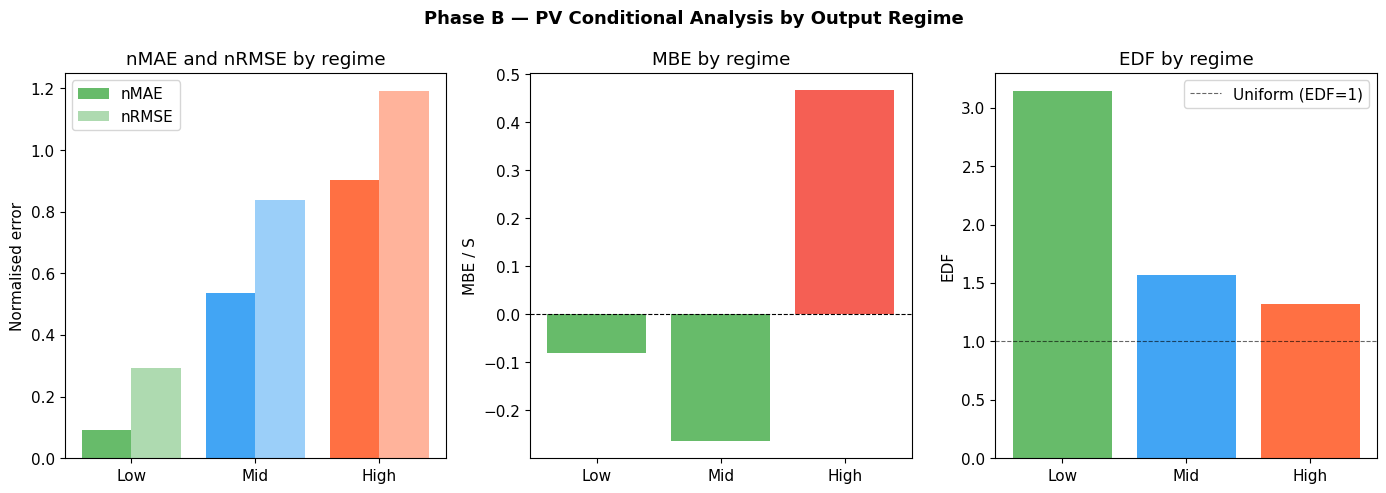

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

regimes = ['Low', 'Mid', 'High']
x = np.arange(len(regimes))
colors = ['#4CAF50', '#2196F3', '#FF5722']

# nMAE and nRMSE
axes[0].bar(x - 0.2, regime_pv['nMAE'],  0.4, label='nMAE',  color=colors, alpha=0.85)
axes[0].bar(x + 0.2, regime_pv['nRMSE'], 0.4, label='nRMSE', color=colors, alpha=0.45)
axes[0].set_title('nMAE and nRMSE by regime')
axes[0].set_xticks(x); axes[0].set_xticklabels(regimes)
axes[0].set_ylabel('Normalised error')
axes[0].legend()

# MBE
bar_colors = ['#F44336' if v > 0 else '#4CAF50' for v in regime_pv['MBE']]
axes[1].bar(x, regime_pv['MBE'], color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('MBE by regime')
axes[1].set_xticks(x); axes[1].set_xticklabels(regimes)
axes[1].set_ylabel('MBE / S')

# EDF
axes[2].bar(x, regime_pv['EDF'], color=colors, alpha=0.85)
axes[2].axhline(1, color='black', linewidth=0.8, linestyle='--', alpha=0.6, label='Uniform (EDF=1)')
axes[2].set_title('EDF by regime')
axes[2].set_xticks(x); axes[2].set_xticklabels(regimes)
axes[2].set_ylabel('EDF')
axes[2].legend()

plt.suptitle('Phase B — PV Conditional Analysis by Output Regime', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_b_pv_regime.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# Compute mean error and MAE for each clock hour (0-23)
pv_active['hour'] = pv_active['Datetime'].dt.hour

hourly = pv_active.groupby('hour').agg(
    mean_error=('error', 'mean'),
    MAE=('error', lambda x: x.abs().mean()),
    n=('error', 'count')
).reset_index()

print("Phase C — PV Hourly Error Profile")
print(hourly.to_string())

# gwMAE_h = sum(|error| * Actuals) / sum(Actuals) per hour
pv_active['abs_error'] = pv_active['error'].abs()
pv_active['weighted_error'] = pv_active['abs_error'] * pv_active['Actuals']

gwmae = pv_active.groupby('hour').apply(
    lambda g: g['weighted_error'].sum() / g['Actuals'].sum()
).reset_index()
gwmae.columns = ['hour', 'gwMAE']

hourly = hourly.merge(gwmae, on='hour')
print(hourly[['hour', 'MAE', 'gwMAE', 'mean_error']].to_string())



Phase C — PV Hourly Error Profile
    hour  mean_error       MAE     n
0      3   -0.000720  0.013513   233
1      4   -0.002772  0.090168   463
2      5    0.008618  0.277107   674
3      6    0.017373  0.559336   885
4      7    0.025204  0.834674  1095
5      8    0.051155  1.240069  1095
6      9    0.100100  1.527921  1095
7     10    0.193800  1.723522  1095
8     11    0.185699  1.732340  1095
9     12    0.162230  1.595896  1095
10    13    0.132834  1.405975  1095
11    14    0.064461  1.099024  1095
12    15    0.038281  0.711641  1095
13    16    0.006824  0.365476  1091
14    17   -0.005566  0.127575  1084
15    18   -0.004643  0.068375   443
16    19   -0.006087  0.010631   350
17    20    0.000063  0.000231   249
18    21   -0.008179  0.008391   210
19    22    0.000131  0.000183   179
20    23   -0.008689  0.008984   173
    hour       MAE     gwMAE  mean_error
0      3  0.013513  0.015902   -0.000720
1      4  0.090168  0.113947   -0.002772
2      5  0.277107  0.393521 

/var/folders/lw/9rf5ssf12y57gz5nz8d45rlc0000gn/T/ipykernel_54875/1754275647.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gwmae = pv_active.groupby('hour').apply(


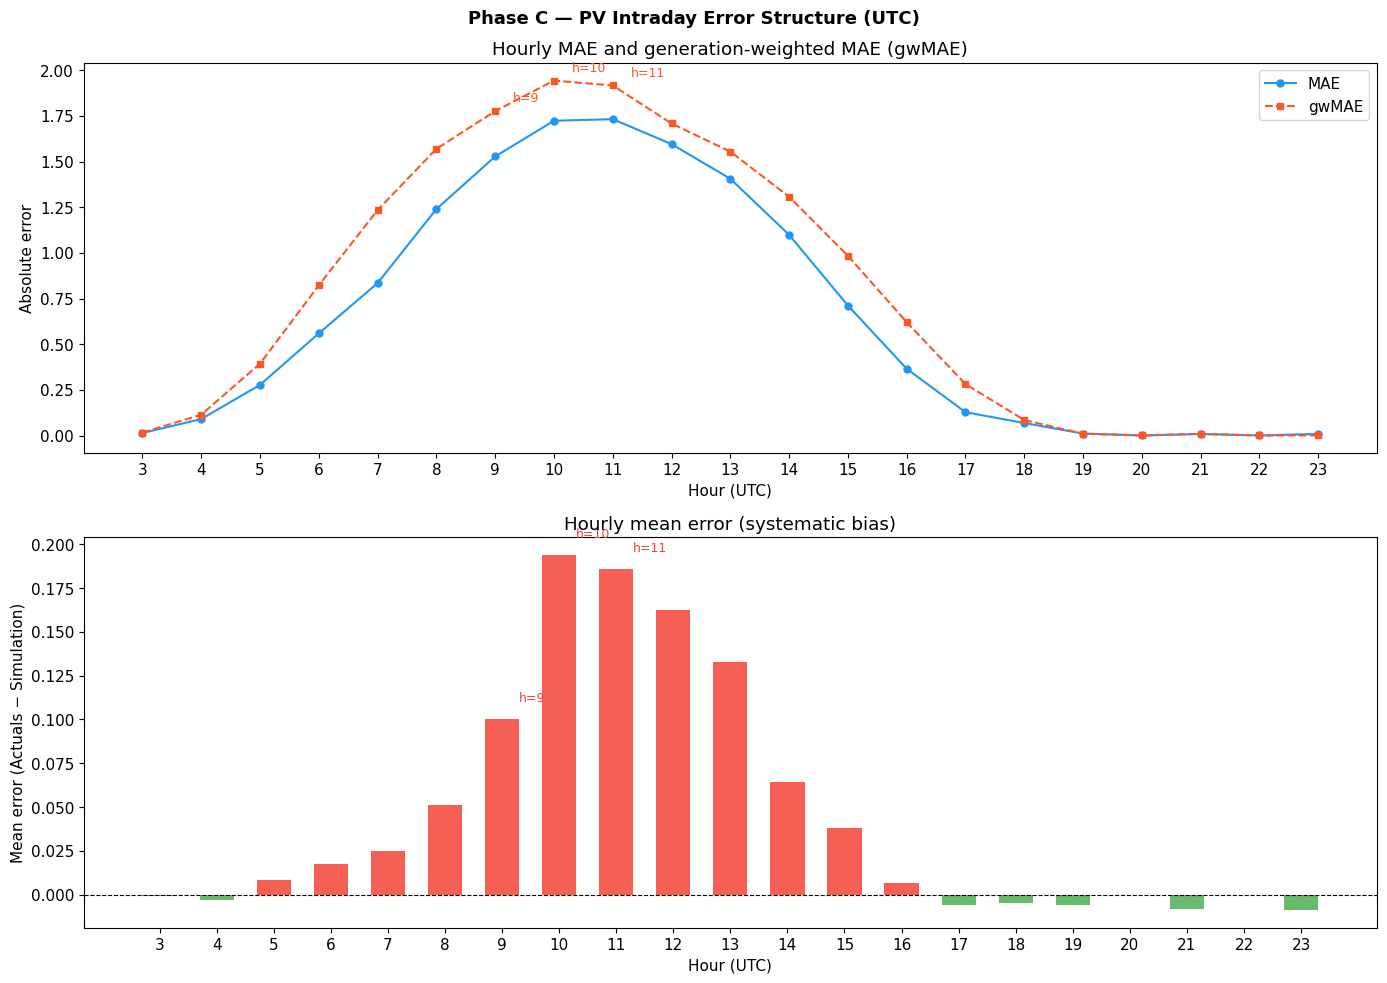

In [14]:
# Filter to meaningful solar hours only (n > 100)
hourly_plot = hourly[hourly['n'] > 100].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

x = hourly_plot['hour']

# Panel 1: MAE vs gwMAE
axes[0].plot(x, hourly_plot['MAE'],   marker='o', markersize=5, 
             color='#2196F3', label='MAE')
axes[0].plot(x, hourly_plot['gwMAE'], marker='s', markersize=5, 
             color='#FF5722', linestyle='--', label='gwMAE')
axes[0].set_title('Hourly MAE and generation-weighted MAE (gwMAE)')
axes[0].set_ylabel('Absolute error')
axes[0].set_xlabel('Hour (UTC)')
axes[0].legend()
axes[0].set_xticks(x)

# Annotate worst hours
for h in [10, 11, 9]:
    row = hourly_plot[hourly_plot['hour'] == h].iloc[0]
    axes[0].annotate(f'h={h}', xy=(h, row['gwMAE']),
                     xytext=(h + 0.3, row['gwMAE'] + 0.05),
                     fontsize=9, color='#FF5722')

# Panel 2: mean error (systematic bias)
bar_colors = ['#F44336' if v > 0 else '#4CAF50' 
              for v in hourly_plot['mean_error']]
axes[1].bar(x, hourly_plot['mean_error'], color=bar_colors, alpha=0.85, width=0.6)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Hourly mean error (systematic bias)')
axes[1].set_ylabel('Mean error (Actuals − Simulation)')
axes[1].set_xlabel('Hour (UTC)')
axes[1].set_xticks(x)

# Annotate worst hours
for h in [10, 11, 9]:
    row = hourly_plot[hourly_plot['hour'] == h].iloc[0]
    axes[1].annotate(f'h={h}', xy=(h, row['mean_error']),
                     xytext=(h + 0.3, row['mean_error'] + 0.01),
                     fontsize=9, color='#F44336')

plt.suptitle('Phase C — PV Intraday Error Structure (UTC)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase_c_pv.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
np.random.seed(42)
B = 5000
worst_hours = [10, 11, 12]

# Pivot to daily error matrix: rows = dates, columns = hours
pv_active['date'] = pv_active['Datetime'].dt.date
daily_pivot = pv_active.pivot_table(
    index='date', columns='hour', values='error', aggfunc='mean'
)

results = {}
for h in worst_hours:
    # Extract daily errors for this hour (drop NaN = days with no active obs)
    daily_errors = daily_pivot[h].dropna().values
    n_days = len(daily_errors)
    
    # Bootstrap: resample days with replacement (block = 1 day)
    boot_means = np.array([
        np.random.choice(daily_errors, size=n_days, replace=True).mean()
        for _ in range(B)
    ])
    
    ci_low  = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)
    obs_mean = daily_errors.mean()
    excludes_zero = not (ci_low <= 0 <= ci_high)
    
    results[f'Hour {h}'] = {
        'n_days':       n_days,
        'mean_error':   round(obs_mean, 4),
        'CI_2.5%':      round(ci_low, 4),
        'CI_97.5%':     round(ci_high, 4),
        'excludes_zero': excludes_zero
    }

bootstrap_pv = pd.DataFrame(results).T
print("Phase C — Bootstrap 95% CI for worst hours (B=5000)")
print(bootstrap_pv.to_string())


Phase C — Bootstrap 95% CI for worst hours (B=5000)
        n_days mean_error CI_2.5% CI_97.5% excludes_zero
Hour 10   1095     0.1938   0.056   0.3295          True
Hour 11   1095     0.1857  0.0475   0.3204          True
Hour 12   1095     0.1622  0.0364   0.2912          True


In [20]:

# =============================================================================
# Phase D — Primary Benchmark Construction (PV)
# Benchmark type : month x hour climatology
# Training period: 2013 active hours only (Actuals > 0)
# Application    : out-of-sample 2014-2015
# Logic          : for each (month, hour) cell, compute mean Actuals in 2013
#                  this serves as the benchmark forecast for all matching
#                  observations in 2014-2015
# =============================================================================
pv_2013 = pv_active[pv_active['Datetime'].dt.year == 2013].copy()

climatology_primary = (
    pv_2013.groupby(['month', 'hour'])['Actuals']
    .mean()
    .reset_index()
    .rename(columns={'Actuals': 'bench_primary'})
)

print(f"Primary benchmark cells: {len(climatology_primary)}")
print(climatology_primary.head(10).to_string())
print()
print(climatology_primary['month'].unique())
print(climatology_primary.groupby('month').size())





Primary benchmark cells: 190
   month  hour  bench_primary
0      1     7       0.084255
1      1     8       0.512614
2      1     9       1.046683
3      1    10       1.423181
4      1    11       1.595311
5      1    12       1.606122
6      1    13       1.217900
7      1    14       0.651585
8      1    15       0.148535
9      1    16       0.001650

[ 1  2  3  4  5  6  7  8  9 10 11 12]
month
1     11
2     12
3     13
4     19
5     21
6     21
7     21
8     20
9     16
10    13
11    12
12    11
dtype: int64


Unmatched observations: 0

T = 24 monthly observations
         ym  MAE_model  MAE_bench    n   delta_l  model_wins
0   2014-01   0.338038   0.368453  341 -0.030415        True
1   2014-02   0.749589   0.589639  333  0.159950       False
2   2014-03   1.056176   0.796418  395  0.259758       False
3   2014-04   0.904691   0.739777  464  0.164915       False
4   2014-05   1.308032   1.007477  562  0.300555       False
5   2014-06   0.904005   0.745899  588  0.158105       False
6   2014-07   1.219273   0.791671  606  0.427602       False
7   2014-08   1.095259   0.925409  515  0.169850       False
8   2014-09   1.373321   1.075364  403  0.297957       False
9   2014-10   0.889183   0.760048  391  0.129135       False
10  2014-11   0.386102   0.355740  355  0.030362       False
11  2014-12   0.273306   0.234869  340  0.038438       False
12  2015-01   0.348167   0.410100  339 -0.061933        True
13  2015-02   0.766628   0.592207  332  0.174421       False
14  2015-03   1.095928   1.001

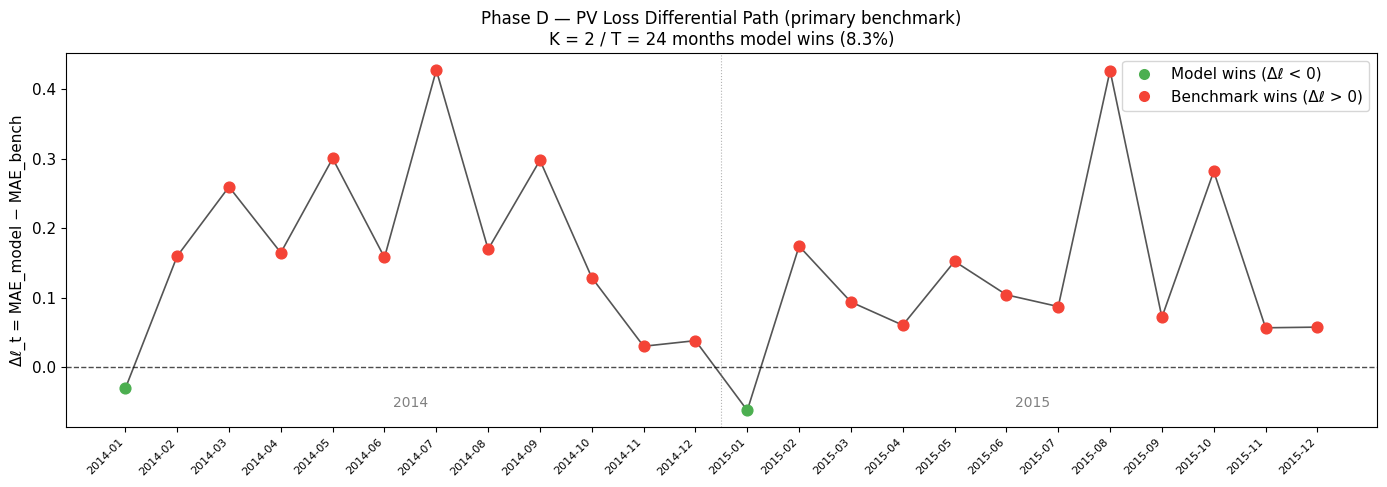

In [23]:
# =============================================================================
# Loss Differential Series (PV, primary benchmark)
# Out-of-sample period: 2014-2015 active hours
# For each month t: delta_l_t = MAE_model_t - MAE_bench_t
# Negative delta_l_t means model beats benchmark in month t
# =============================================================================

# Restrict to out-of-sample active hours
pv_oos = pv_active[pv_active['Datetime'].dt.year.isin([2014, 2015])].copy()

# Merge benchmark forecasts
pv_oos = pv_oos.merge(climatology_primary, on=['month', 'hour'], how='left')

# Check for unmatched cells
n_missing = pv_oos['bench_primary'].isna().sum()
print(f"Unmatched observations: {n_missing}")

# Compute monthly MAE for model and benchmark
pv_oos['ae_model'] = (pv_oos['Actuals'] - pv_oos['Simulation']).abs()
pv_oos['ae_bench'] = (pv_oos['Actuals'] - pv_oos['bench_primary']).abs()

monthly_loss = pv_oos.groupby('ym').agg(
    MAE_model=('ae_model', 'mean'),
    MAE_bench=('ae_bench', 'mean'),
    n=('ae_model', 'count')
).reset_index()

monthly_loss['delta_l'] = monthly_loss['MAE_model'] - monthly_loss['MAE_bench']
monthly_loss['model_wins'] = monthly_loss['delta_l'] < 0

print(f"\nT = {len(monthly_loss)} monthly observations")
print(monthly_loss.to_string())

# =============================================================================
# plot the loss differential path
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(monthly_loss))
labels = [str(p) for p in monthly_loss['ym']]
colors = ['#4CAF50' if v < 0 else '#F44336' for v in monthly_loss['delta_l']]

# Line
ax.plot(x, monthly_loss['delta_l'], color='#555555', linewidth=1.2, zorder=1)

# Dots coloured by win/loss
for i, (xi, yi, c) in enumerate(zip(x, monthly_loss['delta_l'], colors)):
    ax.scatter(xi, yi, color=c, s=60, zorder=2)

# Reference line and year separator
ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(11.5, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(5.5,  monthly_loss['delta_l'].min() * 0.92, '2014', ha='center', fontsize=10, color='grey')
ax.text(17.5, monthly_loss['delta_l'].min() * 0.92, '2015', ha='center', fontsize=10, color='grey')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Δℓ_t = MAE_model − MAE_bench')
ax.set_title(
    f'Phase D — PV Loss Differential Path (primary benchmark)\n'
    f'K = 2 / T = 24 months model wins ({2/24*100:.1f}%)',
    fontsize=12
)
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4CAF50', 
               markersize=9, label='Model wins (Δℓ < 0)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#F44336', 
               markersize=9, label='Benchmark wins (Δℓ > 0)')
], loc='upper right')

plt.tight_layout()
plt.savefig('phase_d_pv_loss_path.png', dpi=150, bbox_inches='tight')
plt.show()



In [25]:

# =============================================================================
# Sign Test + HLN-corrected Diebold-Mariano Test (PV)
# H0: model and benchmark equally likely to win (p = 0.5)
# H1: model wins more often than chance (p > 0.5)
# =============================================================================

delta_l = monthly_loss['delta_l'].values
T = len(delta_l)
K = (delta_l < 0).sum()

# --- Sign test ---
# One-sided exact binomial p-value (H1: p > 0.5)
sign_p = binom.sf(K - 1, T, 0.5)
print(f"Sign test:  K = {K} / T = {T}  ({K/T*100:.1f}%),  p = {sign_p:.4f}")

# --- HLN-corrected DM test ---
delta_bar = delta_l.mean()

# Newey-West HAC standard error, bandwidth = floor(T^(1/3))
bw = int(np.floor(T ** (1/3)))
print(f"\nHAC bandwidth: {bw}")

n = T
gamma0 = np.var(delta_l, ddof=0)
hac_var = gamma0
for lag in range(1, bw + 1):
    gamma_lag = np.mean(
        (delta_l[lag:] - delta_bar) * (delta_l[:-lag] - delta_bar)
    )
    hac_var += 2 * (1 - lag / (bw + 1)) * gamma_lag

se_hac = np.sqrt(hac_var / T)

# HLN small-sample correction (h=1)
h = 1
dm_raw  = delta_bar / se_hac
hln_correction = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
dm_star = dm_raw * hln_correction

# One-sided p-value: H1: E[delta_l] < 0 (model better)
p_dm = t_dist.cdf(dm_star, df=T-1)
print(f"\nDM test (HLN-corrected):")
print(f"  delta_bar = {delta_bar:.4f}")
print(f"  SE_HAC    = {se_hac:.4f}")
print(f"  DM*       = {dm_star:.4f}")
print(f"  p-value   = {p_dm:.4f}  (one-sided, H1: model better)")


Sign test:  K = 2 / T = 24  (8.3%),  p = 1.0000

HAC bandwidth: 2

DM test (HLN-corrected):
  delta_bar = 0.1506
  SE_HAC    = 0.0284
  DM*       = 5.1959
  p-value   = 1.0000  (one-sided, H1: model better)


In [26]:
# =============================================================================
# Giacomini-Rossi Fluctuation Test (PV, primary benchmark)
# GR(t,m) = sqrt(m) * mu_hat(t,m) / sqrt(f_hat)
# where f_hat = full-sample Newey-West HAC variance
# Critical values (GR 2010, Table 1, m=6): 2.55 (5%), 3.394 (1%)
# =============================================================================

def gr_test(delta_l, m):
    T = len(delta_l)
    delta_bar = delta_l.mean()

    # Full-sample Newey-West HAC variance
    bw = int(np.floor(T ** (1/3)))
    gamma0 = np.var(delta_l, ddof=0)
    hac_var = gamma0
    for lag in range(1, bw + 1):
        gamma_lag = np.mean(
            (delta_l[lag:] - delta_bar) * (delta_l[:-lag] - delta_bar)
        )
        hac_var += 2 * (1 - lag / (bw + 1)) * gamma_lag

    # Rolling GR statistics
    gr_stats = []
    for t in range(m - 1, T):
        window = delta_l[t - m + 1 : t + 1]
        mu_hat = window.mean()
        se_mu  = np.sqrt(hac_var / m)   # = sqrt(f_hat / m)
        gr     = mu_hat / se_mu          # = sqrt(m) * mu_hat / sqrt(f_hat)
        gr_stats.append({'t': t, 'gr': gr, 'mu_hat': mu_hat})

    return pd.DataFrame(gr_stats)

delta_l = monthly_loss['delta_l'].values

# Primary window m=6, robustness m in {4, 8}
results_gr = {}
for m in [4, 6, 8]:
    gr_df = gr_test(delta_l, m)
    sup_gr = gr_df['gr'].abs().max()
    results_gr[f'm={m}'] = {
        'sup|GR|':   round(sup_gr, 4),
        'cv_5%':     2.55,
        'cv_1%':     3.394,
        'reject_5%': sup_gr > 2.55,
        'reject_1%': sup_gr > 3.394
    }

gr_summary = pd.DataFrame(results_gr).T
print("GR Fluctuation Test — PV (primary benchmark)")
print(gr_summary.to_string())


GR Fluctuation Test — PV (primary benchmark)
    sup|GR| cv_5%  cv_1% reject_5% reject_1%
m=4  3.7998  2.55  3.394      True      True
m=6  4.4623  2.55  3.394      True      True
m=8  4.9323  2.55  3.394      True      True


In [27]:
# =============================================================================
# Phase D — Secondary Benchmark Construction (PV)
# Benchmark type : ISO week x hour climatology
# Training period: 2013 active hours only (Actuals > 0)
# ISO year filter: enforced to avoid year-end boundary contamination
# Application    : out-of-sample 2014-2015
# =============================================================================

pv_2013 = pv_active[pv_active['Datetime'].dt.year == 2013].copy()

iso = pv_2013['Datetime'].dt.isocalendar()
pv_2013['iso_year'] = iso.year.astype(int)
pv_2013['isoweek']  = iso.week.astype(int)
pv_2013['hour']     = pv_2013['Datetime'].dt.hour

# Enforce ISO year = 2013 to avoid boundary contamination
pv_2013 = pv_2013[pv_2013['iso_year'] == 2013].copy()

climatology_secondary = (
    pv_2013.groupby(['isoweek', 'hour'])['Actuals']
    .mean()
    .reset_index()
    .rename(columns={'Actuals': 'bench_secondary'})
)

cell_counts = pv_2013.groupby(['isoweek', 'hour']).size()

print(f"Secondary benchmark cells: {len(climatology_secondary)}")
print(f"Min obs per cell: {cell_counts.min()}")
print(f"Max obs per cell: {cell_counts.max()}")
print(f"Mean obs per cell: {cell_counts.mean():.1f}")


Secondary benchmark cells: 795
Min obs per cell: 1
Max obs per cell: 7
Mean obs per cell: 6.6


In [36]:
# =============================================================================
# Phase D — Secondary Benchmark Loss Differential (PV)
# Work on a clean copy to avoid polluting pv_oos
# =============================================================================

pv_oos_sec = pv_oos[['Datetime', 'ym', 'month', 'hour', 
                      'Actuals', 'Simulation', 
                      'ae_model', 'bench_primary']].copy()

# Add isoweek
pv_oos_sec['isoweek'] = pv_oos_sec['Datetime'].dt.isocalendar().week.astype(int)

# Merge secondary benchmark and cell counts
pv_oos_sec = pv_oos_sec.merge(climatology_secondary, on=['isoweek', 'hour'], how='left')
pv_oos_sec = pv_oos_sec.merge(cell_counts, on=['isoweek', 'hour'], how='left')

# Fallback: sparse cells use primary benchmark
mask_sparse = pv_oos_sec['n_obs'] < 3
pv_oos_sec.loc[mask_sparse, 'bench_secondary'] = pv_oos_sec.loc[mask_sparse, 'bench_primary']

n_fallback = mask_sparse.sum()
print(f"Observations using fallback: {n_fallback} ({n_fallback/len(pv_oos_sec)*100:.1f}%)")

# Monthly loss differential
pv_oos_sec['ae_bench_sec'] = (pv_oos_sec['Actuals'] - pv_oos_sec['bench_secondary']).abs()

monthly_loss_sec = pv_oos_sec.groupby('ym').agg(
    MAE_model=('ae_model', 'mean'),
    MAE_bench_sec=('ae_bench_sec', 'mean'),
    n=('ae_model', 'count')
).reset_index()

monthly_loss_sec['delta_l']    = monthly_loss_sec['MAE_model'] - monthly_loss_sec['MAE_bench_sec']
monthly_loss_sec['model_wins'] = monthly_loss_sec['delta_l'] < 0

print(f"\nT = {len(monthly_loss_sec)} monthly observations")
print(monthly_loss_sec[['ym', 'MAE_model', 'MAE_bench_sec', 'delta_l', 'model_wins']].to_string())


Observations using fallback: 129 (1.2%)

T = 24 monthly observations
         ym  MAE_model  MAE_bench_sec   delta_l  model_wins
0   2014-01   0.338038       0.407314 -0.069276        True
1   2014-02   0.749589       0.531383  0.218207       False
2   2014-03   1.056176       0.876018  0.180158       False
3   2014-04   0.904691       0.778872  0.125820       False
4   2014-05   1.308032       1.035691  0.272341       False
5   2014-06   0.904005       0.805611  0.098394       False
6   2014-07   1.219273       0.932600  0.286673       False
7   2014-08   1.095259       0.960026  0.135233       False
8   2014-09   1.373321       1.151072  0.222249       False
9   2014-10   0.889183       0.832518  0.056665       False
10  2014-11   0.386102       0.349523  0.036579       False
11  2014-12   0.273306       0.261260  0.012046       False
12  2015-01   0.348167       0.437281 -0.089113        True
13  2015-02   0.766628       0.604244  0.162385       False
14  2015-03   1.095928       1.

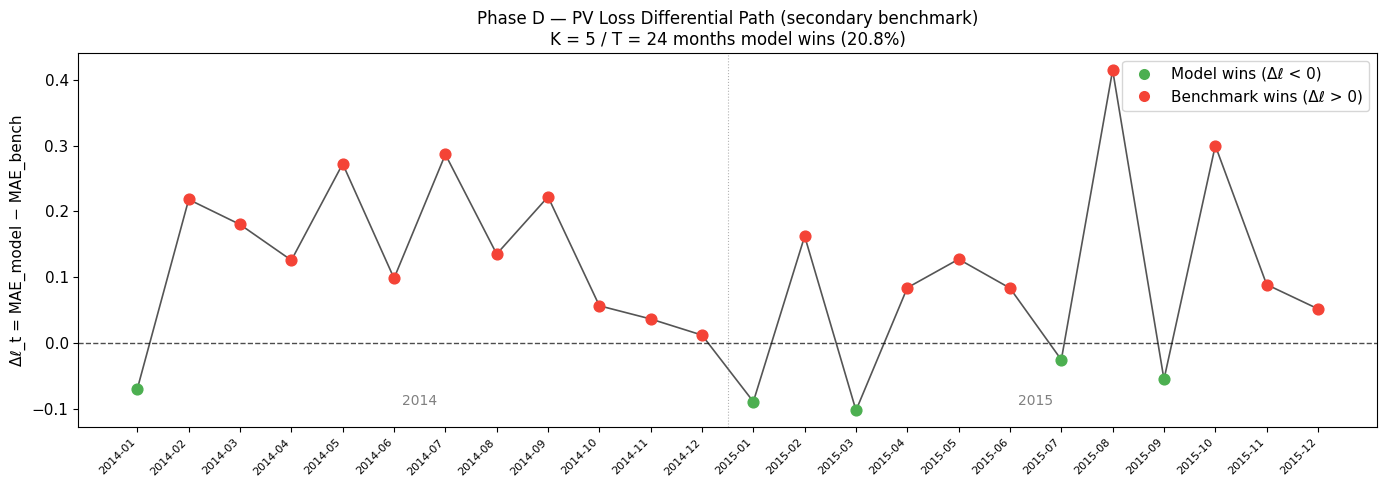

In [37]:
# =============================================================================
# Phase D — Loss Differential Path (PV, secondary benchmark)
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(monthly_loss_sec))
labels = [str(p) for p in monthly_loss_sec['ym']]
colors = ['#4CAF50' if v < 0 else '#F44336' 
          for v in monthly_loss_sec['delta_l']]

ax.plot(x, monthly_loss_sec['delta_l'], color='#555555', linewidth=1.2, zorder=1)
for xi, yi, c in zip(x, monthly_loss_sec['delta_l'], colors):
    ax.scatter(xi, yi, color=c, s=60, zorder=2)

ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.7)
ax.axvline(11.5, color='grey', linewidth=0.8, linestyle=':', alpha=0.6)
ax.text(5.5,  monthly_loss_sec['delta_l'].min() * 0.92, '2014',
        ha='center', fontsize=10, color='grey')
ax.text(17.5, monthly_loss_sec['delta_l'].min() * 0.92, '2015',
        ha='center', fontsize=10, color='grey')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Δℓ_t = MAE_model − MAE_bench')
ax.set_title(
    f'Phase D — PV Loss Differential Path (secondary benchmark)\n'
    f'K = 5 / T = 24 months model wins ({5/24*100:.1f}%)',
    fontsize=12
)
ax.legend(handles=[
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4CAF50',
               markersize=9, label='Model wins (Δℓ < 0)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#F44336',
               markersize=9, label='Benchmark wins (Δℓ > 0)')
], loc='upper right')

plt.tight_layout()
plt.savefig('phase_d_pv_loss_path_secondary.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# =============================================================================
# Phase D — Sign Test + HLN-DM Test + GR Test (PV, secondary benchmark)
# =============================================================================

delta_l_sec = monthly_loss_sec['delta_l'].values
T = len(delta_l_sec)
K_sec = (delta_l_sec < 0).sum()

# --- Sign test ---
sign_p_sec = binom.sf(K_sec - 1, T, 0.5)
print(f"Sign test:  K = {K_sec} / T = {T}  ({K_sec/T*100:.1f}%),  p = {sign_p_sec:.4f}")

# --- HLN-corrected DM test ---
delta_bar_sec = delta_l_sec.mean()
bw = int(np.floor(T ** (1/3)))
gamma0 = np.var(delta_l_sec, ddof=0)
hac_var_sec = gamma0
for lag in range(1, bw + 1):
    gamma_lag = np.mean(
        (delta_l_sec[lag:] - delta_bar_sec) * (delta_l_sec[:-lag] - delta_bar_sec)
    )
    hac_var_sec += 2 * (1 - lag / (bw + 1)) * gamma_lag

se_hac_sec  = np.sqrt(hac_var_sec / T)
h = 1
dm_raw_sec  = delta_bar_sec / se_hac_sec
hln_corr    = np.sqrt((T + 1 - 2*h + h*(h-1)/T) / T)
dm_star_sec = dm_raw_sec * hln_corr
p_dm_sec    = t_dist.cdf(dm_star_sec, df=T-1)

print(f"\nDM test (HLN-corrected):")
print(f"  delta_bar = {delta_bar_sec:.4f}")
print(f"  SE_HAC    = {se_hac_sec:.4f}")
print(f"  DM*       = {dm_star_sec:.4f}")
print(f"  p-value   = {p_dm_sec:.4f}  (one-sided, H1: model better)")

# --- GR fluctuation test ---
print(f"\nGR Fluctuation Test (secondary benchmark):")
results_gr_sec = {}
for m in [4, 6, 8]:
    gr_df = gr_test(delta_l_sec, m)
    sup_gr = gr_df['gr'].abs().max()
    results_gr_sec[f'm={m}'] = {
        'sup|GR|':    round(sup_gr, 4),
        'cv_5%':      2.55,
        'cv_1%':      3.394,
        'reject_5%':  sup_gr > 2.55,
        'reject_1%':  sup_gr > 3.394
    }

gr_summary_sec = pd.DataFrame(results_gr_sec).T
print(gr_summary_sec.to_string())


Sign test:  K = 5 / T = 24  (20.8%),  p = 0.9992

DM test (HLN-corrected):
  delta_bar = 0.1090
  SE_HAC    = 0.0247
  DM*       = 4.3181
  p-value   = 0.9999  (one-sided, H1: model better)

GR Fluctuation Test (secondary benchmark):
    sup|GR| cv_5%  cv_1% reject_5% reject_1%
m=4  3.2899  2.55  3.394      True     False
m=6  3.9848  2.55  3.394      True      True
m=8   4.495  2.55  3.394      True      True
